<a href="https://colab.research.google.com/github/sarakhaderkoko1233-wq/assignment-ml/blob/assignment/assingment_ml2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# 1.Import libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
# 2. Load Dataset
df = pd.read_csv("/content/Iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [5]:
# 3.Preprocessing

df = df.dropna()
# df = df.drop(['column_name'], axis=1)
X = df.select_dtypes(include=['float64', 'int64'])
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Explained Variance: [0.7470533  0.18435257]


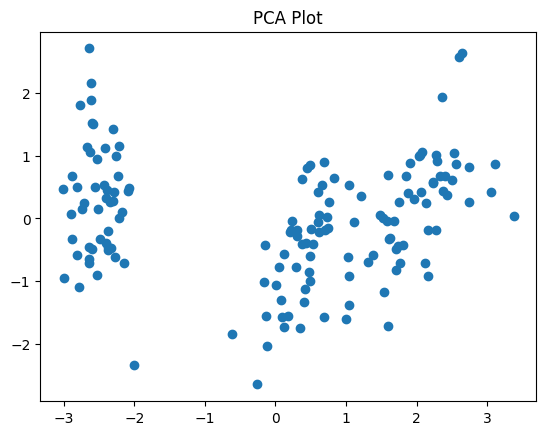

In [6]:
# 4.PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Plot")
plt.show()

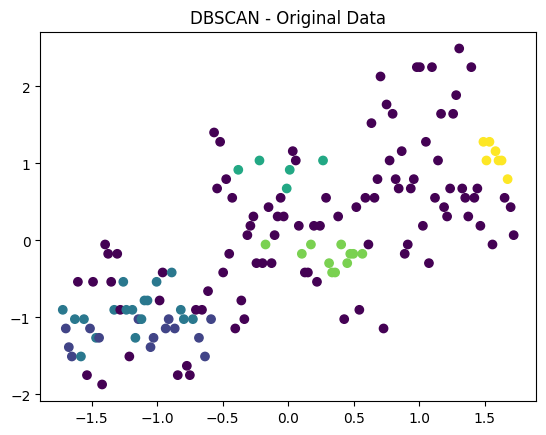

In [7]:
# 5.DBSCAN (Original Data)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_original = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_original)
plt.title("DBSCAN - Original Data")
plt.show()


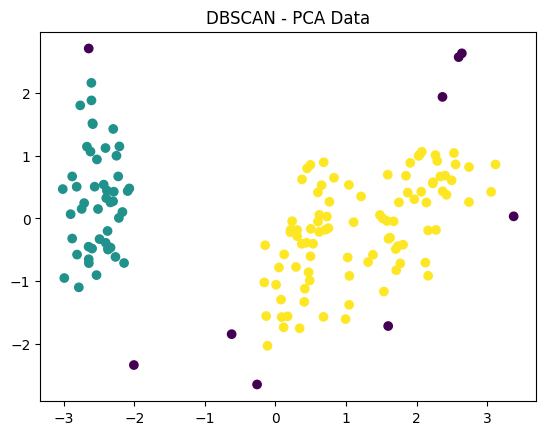

In [8]:
# 6.DBSCAN (PCA Data)

dbscan_pca = DBSCAN(eps=0.5, min_samples=5)
labels_pca = dbscan_pca.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca)
plt.title("DBSCAN - PCA Data")
plt.show()

In [9]:
# 7.Analysis

print("Clusters (Original):", len(set(labels_original)) - (1 if -1 in labels_original else 0))
print("Noise points (Original):", list(labels_original).count(-1))

print("Clusters (PCA):", len(set(labels_pca)) - (1 if -1 in labels_pca else 0))
print("Noise points (PCA):", list(labels_pca).count(-1))

Clusters (Original): 5
Noise points (Original): 95
Clusters (PCA): 2
Noise points (PCA): 9
